# RCWA for a single uniform (homogeneous) layer

A finite, unpatterned slab of thickness `thickness` and permittivity `eps_film`
sits between two semi-infinite media (`eps_inc`, `eps_sub`). 

**Two solver pipelines, one physical layer.** A `Layer` with no `shape_fn` is
"uniform": `LayerSolver.prepare` routes it to the closed-form
`homogeneous_modes`. Give the *same* physical layer an all-ones `shape_fn` plus a `medium_void`
equal to `medium_solid`, and it instead goes through `compute_isotropic` +
`eigsolver` -- the general patterned-layer path, just handed a trivial
pattern. Every example below solves the "eigen" pipeline at least once and
checks it agrees with "homogeneous" to numerical precision, since the two
should be indistinguishable for a physically uniform layer.

Each section compares RCWA against an independent closed-form analytic
reference (`tmm_rt`, a transfer-matrix method generalizing `interface.ipynb`'s
single-interface `fresnel_rt` to multilayer stacks), prints the MSE between
them, and marks the relevant special wavelength/angle on the plots.

1. **Dielectric film** -- Fabry&#8211;P&#233;rot interference, R/T vs wavelength.
2. **SiN film on Si substrate** -- real dispersive materials, varying
   thickness and incidence angle.
3. **Surface plasmon resonance** -- Au film, Kretschmann and Otto
   configurations, R vs angle.

In [1]:
""" Helper functions """
import math
import torch
from typing import Optional, Sequence, Tuple

from dispertorch import ConstantEps, material
from metarcwa import IsotropicMedium, Layer, Source, Stack, Lattice, Model
from metarcwa.model.adapters import from_dispertorch
from metarcwa.model.utils import CallableModule
from metarcwa import Config, Solver
from metarcwa import Observables
import matplotlib.pyplot as plt


def _medium(eps_model) -> IsotropicMedium:
    """Wrap a DisperTorch dispersion model (e.g. ``ConstantEps`` or
    ``dispertorch.material(...)``) into a metarcwa ``IsotropicMedium``."""
    return IsotropicMedium(from_dispertorch(eps_model))


def _uniform_mask() -> CallableModule:
    """All-ones ``shape_fn``: makes a physically-uniform layer look
    "patterned" to ``Layer``, so it is routed through ``compute_isotropic`` +
    ``eigsolver`` instead of the closed-form ``homogeneous_modes`` path. Used
    only to cross-check the eigensolver pipeline against the fast
    homogeneous one -- there is no physical reason to prefer it here.
    """
    return CallableModule(lambda lattice, nx, ny: torch.ones((ny, nx)))


def build_model(eps_inc,
                eps_film,
                eps_sub,
                thickness: torch.Tensor,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor,
                phi: torch.Tensor,
                method: str = "homogeneous") -> Model:
    """Build a Model for a single finite layer between two half-spaces.

    Parameters
    ----------
    eps_inc, eps_film, eps_sub : DisperTorch dispersion models
        Incidence half-space, finite layer, and transmission half-space.
    thickness : torch.Tensor
        Finite-layer thickness (same length units as ``wl``).
    period : torch.Tensor
        Lattice period (px = py); physically irrelevant for a uniform layer,
        only needed to define the reciprocal lattice for the harmonic
        expansion.
    wl, theta, phi : torch.Tensor
        Source sweep axes -- free-space wavelength, polar and azimuthal
        incidence angle (radians).
    method : {"homogeneous", "eigen"}
        "homogeneous" (default) builds a plain uniform ``Layer`` (no
        ``shape_fn``), solved by the closed-form ``homogeneous_modes`` path.
        "eigen" gives the same physical layer an all-ones ``shape_fn`` (see
        :func:`_uniform_mask`) plus a ``medium_void`` equal to
        ``medium_solid``, forcing it through the patterned-layer eigensolver
        path instead. Both must give the same S-matrix -- this is the
        toggle used to cross-check the two solver pipelines.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    incidence    = _medium(eps_inc)
    transmission = _medium(eps_sub)
    film         = _medium(eps_film)

    if method == "homogeneous":
        layer = Layer(medium_solid=film, thickness=thickness)
    elif method == "eigen":
        void  = _medium(eps_film)
        layer = Layer(medium_solid=film, thickness=thickness,
                      medium_void=void, shape_fn=_uniform_mask())
    else:
        raise ValueError(f"method must be 'homogeneous' or 'eigen', got {method!r}")

    lattice = Lattice.rectangular(px=period, py=period)
    stack = Stack(incidence, [layer], transmission, lattice)
    src = Source(wl, theta, phi)
    return Model(stack, src)


def build_config(dtype: torch.dtype, device: torch.device, m: int = 1, n: int = 1) -> Config:
    """Solver configuration for these uniform-layer examples.

    ``m=n=1`` with circular truncation keeps just enough harmonics for an
    unpatterned layer (only the specular order carries energy); TVF
    factorization (``factorization=None``) is irrelevant here -- there is no
    patterned geometry to factorize.
    """
    return Config(dtype, device, m=m, n=n, truncation="circular", factorization=None)


def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor, torch.Tensor,
                                                        torch.Tensor, torch.Tensor]:
    """Solve the stack and return specular-order power R/T for both polarizations.

    Same convention as ``interface.ipynb``'s ``compute_rt``: reflectance is
    ``|r|**2``; transmittance additionally carries the Poynting-flux ratio
    ``Re(n_sub*cos(theta_t)) / Re(n_inc*cos(theta_i))`` between the incidence
    and transmission half-spaces (unaffected by whatever finite layer sits in
    between -- it depends only on the two half-spaces and the angle).

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Shape ``[N_wl, N_theta, N_phi]``, matching ``Source``'s sweep axes.
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')
    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)
    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff * torch.abs(ts.cpu())**2
    Tp = coeff * torch.abs(tp.cpu())**2
    return Rs, Rp, Ts, Tp


def tmm_rt(n_list: Sequence[torch.Tensor], d_list: Sequence[float],
          wl: torch.Tensor, theta0: torch.Tensor, pol: str = 'p') -> Tuple[torch.Tensor, torch.Tensor]:
    """Closed-form transfer-matrix R/T for an isotropic multilayer stack.

    Independent reference for the uniform-layer RCWA solve: generalizes
    ``interface.ipynb``'s single-interface ``fresnel_rt`` to an arbitrary
    number of finite layers via the standard 2&#215;2 transfer-matrix method.

    Parameters
    ----------
    n_list : sequence of (possibly dispersive) refractive indices
        Incidence medium first, then one entry per finite layer, then the
        transmission medium last -- length ``len(d_list) + 2``. Each entry
        is a scalar or a tensor broadcastable against ``wl``/``theta0``
        (e.g. ``material('Si3N4')(wl)**0.5`` for a dispersive film).
    d_list : sequence of float
        Thickness of each finite layer, same length units as ``wl``.
    wl : torch.Tensor
        Free-space wavelength(s).
    theta0 : torch.Tensor
        Incidence angle(s) in radians, in the incidence medium.
    pol : {'s', 'p'}

    Returns
    -------
    R, T : torch.Tensor
        Broadcast shape of ``wl``/``theta0``. Uses the same flux-normalization
        convention as :func:`compute_rt` (``T`` scaled by
        ``Re(kz_sub)/Re(kz_inc)``, which for a k0-normalized
        ``kz = n*cos(theta)`` is exactly the Poynting-flux ratio).

    Notes
    -----
    Only one of ``wl``/``theta0`` should vary at a time (matching how the
    examples below sweep either wavelength or angle, never both); mixing two
    independently-batched axes is not exercised here.
    """
    n_list = [torch.as_tensor(n, dtype=torch.complex128) for n in n_list]
    theta0 = torch.as_tensor(theta0, dtype=torch.float64)
    wl = torch.as_tensor(wl, dtype=torch.float64)
    k0 = 2 * torch.pi / wl
    kx = n_list[0] * torch.sin(theta0)
    kz = [torch.sqrt(n**2 - kx**2 + 0j) for n in n_list]

    def rt_ij(i, j):
        ni, nj, kzi, kzj = n_list[i], n_list[j], kz[i], kz[j]
        if pol == 'p':
            r = (nj**2 * kzi - ni**2 * kzj) / (nj**2 * kzi + ni**2 * kzj)
            t = 2 * ni * nj * kzi / (nj**2 * kzi + ni**2 * kzj)
        else:
            r = (kzi - kzj) / (kzi + kzj)
            t = 2 * kzi / (kzi + kzj)
        return r, t

    shape = torch.broadcast_shapes(kx.shape, k0.shape)
    m11 = torch.ones(shape, dtype=torch.complex128)
    m12 = torch.zeros(shape, dtype=torch.complex128)
    m21 = torch.zeros(shape, dtype=torch.complex128)
    m22 = torch.ones(shape, dtype=torch.complex128)

    n_media = len(n_list)
    for i in range(n_media - 1):
        r, t = rt_ij(i, i + 1)
        d11, d12, d21, d22 = 1 / t, r / t, r / t, 1 / t
        m11, m12, m21, m22 = (m11 * d11 + m12 * d21, m11 * d12 + m12 * d22,
                               m21 * d11 + m22 * d21, m21 * d12 + m22 * d22)
        if i + 1 < n_media - 1:
            ph = kz[i + 1] * k0 * d_list[i]
            p11, p22 = torch.exp(-1j * ph), torch.exp(1j * ph)
            m11, m12, m21, m22 = m11 * p11, m12 * p22, m21 * p11, m22 * p22

    r = m21 / m11
    t = 1 / m11
    coeff = torch.real(kz[-1]) / torch.real(kz[0])
    R = r.abs()**2
    T = coeff * t.abs()**2
    return R, T


def mse(a: torch.Tensor, b: torch.Tensor) -> float:
    """Mean squared error between an RCWA curve and its analytic reference."""
    return torch.mean((a.reshape(-1) - b.reshape(-1))**2).item()


def plot_rt_vs_wl(wl_nm, curves, theory=None, marks=None, title=""):
    """Plot Reflection/Transmission vs wavelength -- analogous to
    ``interface.ipynb``'s ``plot_rt`` but with wavelength (nm) on the x-axis.

    Parameters
    ----------
    wl_nm : torch.Tensor
        Wavelength in nm, shape ``[N_wl]``.
    curves : (Rs, Rp, Ts, Tp)
        RCWA curves, already indexed down to 1-D, plotted as solid lines.
    theory : (Rs, Rp, Ts, Tp), optional
        Reference curves overlaid as dashed lines.
    marks : sequence of (wavelength_nm, label), optional
        Special wavelengths drawn as labeled vertical dotted lines.
    """
    Rs, Rp, Ts, Tp = curves
    fig, (ax_r, ax_t) = plt.subplots(2, 1, figsize=(6, 6))

    ax_r.set_title(f'Reflection {title}'.strip())
    ax_r.plot(wl_nm, Rs, color='C0', label='s-pol (RCWA)')
    ax_r.plot(wl_nm, Rp, color='C1', label='p-pol (RCWA)')

    ax_t.set_title(f'Transmission {title}'.strip())
    ax_t.plot(wl_nm, Ts, color='C0', label='s-pol (RCWA)')
    ax_t.plot(wl_nm, Tp, color='C1', label='p-pol (RCWA)')

    if theory is not None:
        Rs_t, Rp_t, Ts_t, Tp_t = theory
        ax_r.plot(wl_nm, Rs_t, color='k', linestyle='--', label='s-pol (TMM)')
        ax_r.plot(wl_nm, Rp_t, color='r', linestyle='--', label='p-pol (TMM)')
        ax_t.plot(wl_nm, Ts_t, color='k', linestyle='--', label='s-pol (TMM)')
        ax_t.plot(wl_nm, Tp_t, color='r', linestyle='--', label='p-pol (TMM)')

    for ax in (ax_r, ax_t):
        ax.set_ylim([0, 1])
        ax.set_xlim([float(wl_nm.min()), float(wl_nm.max())])
        ax.set_xlabel('wavelength (nm)')
        ax.grid(True)
        if marks:
            for wl_mark, label in marks:
                ax.axvline(wl_mark, color='k', linestyle=':', linewidth=1)
                ax.text(wl_mark, 0.5, f' {label}', rotation=90, va='center', ha='left', fontsize=8)

    ax_r.legend(fontsize=8, loc='best')
    fig.tight_layout()


def plot_rt_vs_theta(theta_deg, curves, theory=None, marks=None, title=""):
    """Plot Reflection/Transmission vs incidence angle -- same layout as
    ``plot_rt_vs_wl``, angle (deg) on the x-axis."""
    Rs, Rp, Ts, Tp = curves
    fig, (ax_r, ax_t) = plt.subplots(2, 1, figsize=(6, 6))

    ax_r.set_title(f'Reflection {title}'.strip())
    ax_r.plot(theta_deg, Rs, color='C0', label='s-pol (RCWA)')
    ax_r.plot(theta_deg, Rp, color='C1', label='p-pol (RCWA)')

    ax_t.set_title(f'Transmission {title}'.strip())
    ax_t.plot(theta_deg, Ts, color='C0', label='s-pol (RCWA)')
    ax_t.plot(theta_deg, Tp, color='C1', label='p-pol (RCWA)')

    if theory is not None:
        Rs_t, Rp_t, Ts_t, Tp_t = theory
        ax_r.plot(theta_deg, Rs_t, color='k', linestyle='--', label='s-pol (TMM)')
        ax_r.plot(theta_deg, Rp_t, color='r', linestyle='--', label='p-pol (TMM)')
        ax_t.plot(theta_deg, Ts_t, color='k', linestyle='--', label='s-pol (TMM)')
        ax_t.plot(theta_deg, Tp_t, color='r', linestyle='--', label='p-pol (TMM)')

    for ax in (ax_r, ax_t):
        ax.set_ylim([0, 1])
        ax.set_xlim([float(theta_deg.min()), float(theta_deg.max())])
        ax.set_xlabel('theta (deg)')
        ax.grid(True)
        if marks:
            for angle, label in marks:
                ax.axvline(angle, color='k', linestyle=':', linewidth=1)
                ax.text(angle, 0.5, f' {label}', rotation=90, va='center', ha='left', fontsize=8)

    ax_r.legend(fontsize=8, loc='best')
    fig.tight_layout()

## 1. Dielectric film: Fabry&#8211;P&#233;rot interference

Air (`n=1`) / lossless dielectric film (`n=2`, 150&#8201;nm) / glass substrate
(`n=1.5`), at a fixed oblique incidence (theta&#8776;17&#176; so s/p differ).
Multiple reflections between the two film interfaces interfere
constructively/destructively as wavelength varies, producing Fabry&#8211;P&#233;rot
fringes in `R`/`T`. Solved via both the closed-form homogeneous pipeline and
the eigensolver pipeline (forced with an all-ones `shape_fn`), and compared
against the closed-form transfer-matrix reference `tmm_rt`.

homogeneous vs eigen: max|dRs|=1.37e-15, max|dRp|=1.25e-15
RCWA vs TMM MSE: Rs=9.71e-18, Rp=7.73e-18, Ts=1.54e-15, Tp=1.61e-15


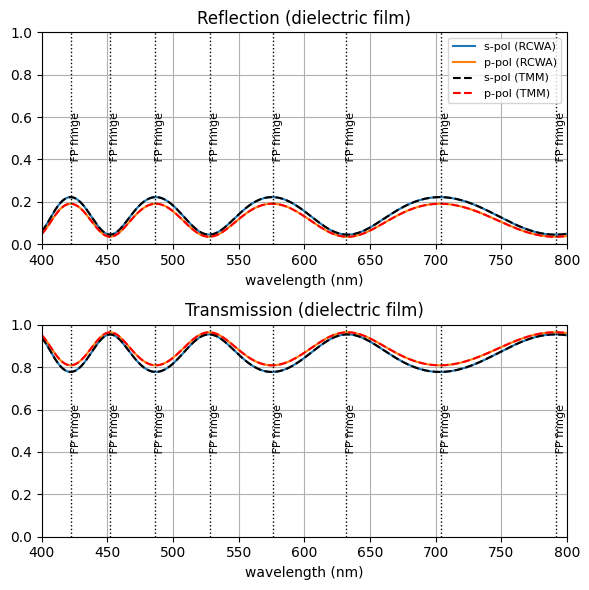

In [2]:
# Define config
dtype = torch.float64
device = "cpu"

# Define model parameters
eps_inc  = ConstantEps(1.0)
eps_film = ConstantEps(4.0)     # n_film = 2
eps_sub  = ConstantEps(2.25)    # n_sub  = 1.5
thickness = torch.tensor(800.0)   # nm
period    = 400.0
wl    = torch.linspace(400.0, 800.0, 201)
theta = torch.tensor([0.3])       # ~17 deg, fixed
phi   = torch.tensor([0.0])

config = build_config(dtype, device)

# Solve via both pipelines and confirm they agree
model_homog = build_model(eps_inc, eps_film, eps_sub, thickness, period, wl, theta, phi, method="homogeneous")
model_eigen = build_model(eps_inc, eps_film, eps_sub, thickness, period, wl, theta, phi, method="eigen")
Rs_h, Rp_h, Ts_h, Tp_h = compute_rt(model_homog, config)
Rs_e, Rp_e, Ts_e, Tp_e = compute_rt(model_eigen, config)
print(f"homogeneous vs eigen: max|dRs|={(Rs_h - Rs_e).abs().max().item():.2e}, "
      f"max|dRp|={(Rp_h - Rp_e).abs().max().item():.2e}")

# Analytic reference (transfer-matrix method)
n1, n2, n3 = 1.0, 2.0, 1.5
Rs_t, Ts_t = tmm_rt([n1, n2, n3], [float(thickness)], wl, theta.item(), pol='s')
Rp_t, Tp_t = tmm_rt([n1, n2, n3], [float(thickness)], wl, theta.item(), pol='p')

print(f"RCWA vs TMM MSE: Rs={mse(Rs_h[:,0,0], Rs_t):.2e}, Rp={mse(Rp_h[:,0,0], Rp_t):.2e}, "
      f"Ts={mse(Ts_h[:,0,0], Ts_t):.2e}, Tp={mse(Tp_h[:,0,0], Tp_t):.2e}")

# Mark Fabry-Perot fringe wavelengths -- numeric local extrema of the
# s-pol reflectance (constructive/destructive interference in the film
# round trip)
Rs_np = Rs_t.numpy()
extrema = [wl[i].item() for i in range(1, len(wl) - 1)
           if (Rs_np[i] - Rs_np[i-1]) * (Rs_np[i+1] - Rs_np[i]) < 0]

plot_rt_vs_wl(
    wl,
    curves=(Rs_h[:, 0, 0], Rp_h[:, 0, 0], Ts_h[:, 0, 0], Tp_h[:, 0, 0]),
    theory=(Rs_t, Rp_t, Ts_t, Tp_t),
    marks=[(w, "FP fringe") for w in extrema],
    title="(dielectric film)",
)

## 2. Real materials: Si&#8323;N&#8324; film on Si substrate

Air / dispersive `Si3N4` film / dispersive `aSi` substrate. Crystalline
silicon absorbs strongly across the visible band, so unlike Part 1 the
reflection dip is not pure interference -- reflected power that is not
absorbed shows up as `R`, and `T`&#8776;0 throughout. Two knobs are varied
independently: film **thickness** (interference fringe spacing/depth shifts)
and **incidence angle** (fringe positions shift and s/p separate). Compared
against `tmm_rt` fed the same dispersive n(&#955;)=&#8730;&#949;(&#955;) curves.

d= 80.0 nm   R range=[0.000, 0.357]   MSE Rs=1.06e-15  MSE Rp=6.95e-16
d=120.0 nm   R range=[0.111, 0.459]   MSE Rs=1.68e-15  MSE Rp=1.35e-15
d=160.0 nm   R range=[0.004, 0.411]   MSE Rs=3.56e-15  MSE Rp=2.88e-15
d=500.0 nm   R range=[0.000, 0.453]   MSE Rs=3.06e-14  MSE Rp=2.25e-14


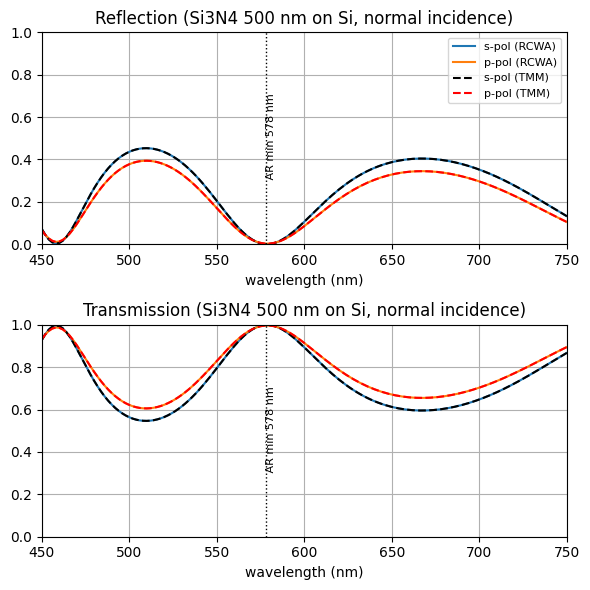

In [3]:
# Define config
dtype = torch.float64
device = "cpu"

# Define model parameters
eps_inc  = ConstantEps(1.0)
eps_film = material('Si3N4')   # dispersive
eps_sub  = material('aSi')     # dispersive, absorbing
period   = 400.0
wl    = torch.linspace(450.0, 750.0, 151)
theta = torch.tensor([0.4])
phi   = torch.tensor([0.0])

config = build_config(dtype, device)
n_film_wl = eps_film(wl)**0.5   # dispersive n(wl), fed straight into tmm_rt
n_sub_wl  = eps_sub(wl)**0.5

# --- vary thickness ---
for th_nm in (80.0, 120.0, 160.0, 500):
    thickness = torch.tensor(th_nm)
    model = build_model(eps_inc, eps_film, eps_sub, thickness, period, wl, theta, phi, method="homogeneous")
    Rs, Rp, Ts, Tp = compute_rt(model, config)
    Rs_t, Ts_t = tmm_rt([1.0, n_film_wl, n_sub_wl], [th_nm], wl, theta, pol='s')
    Rp_t, Tp_t = tmm_rt([1.0, n_film_wl, n_sub_wl], [th_nm], wl, theta, pol='p')
    print(f"d={th_nm:5.1f} nm   R range=[{Rs[:,0,0].min():.3f}, {Rs[:,0,0].max():.3f}]   "
          f"MSE Rs={mse(Rs[:,0,0], Rs_t):.2e}  MSE Rp={mse(Rp[:,0,0], Rp_t):.2e}")
    if th_nm == 500.0:
        # antireflection minimum for this thickness, found numerically
        i_ar = Rs[:, 0, 0].argmin().item()
        ar_wl = wl[i_ar].item()
        plot_rt_vs_wl(
            wl,
            curves=(Rs[:, 0, 0], Rp[:, 0, 0], Ts[:, 0, 0], Tp[:, 0, 0]),
            theory=(Rs_t, Rp_t, Ts_t, Tp_t),
            marks=[(ar_wl, f"AR min {ar_wl:.0f} nm")],
            title=f"(Si3N4 {th_nm:.0f} nm on Si, normal incidence)",
        )

Now fix the thickness and vary the incidence angle instead -- fringe
positions shift with `theta` (the round-trip phase depends on `cos(theta)`
in the film), and s/p reflectances separate away from normal incidence.

theta= 0.0 deg   MSE Rs=3.41e-14   MSE Rp=3.41e-14
theta=40.0 deg   MSE Rs=6.31e-14   MSE Rp=2.21e-14


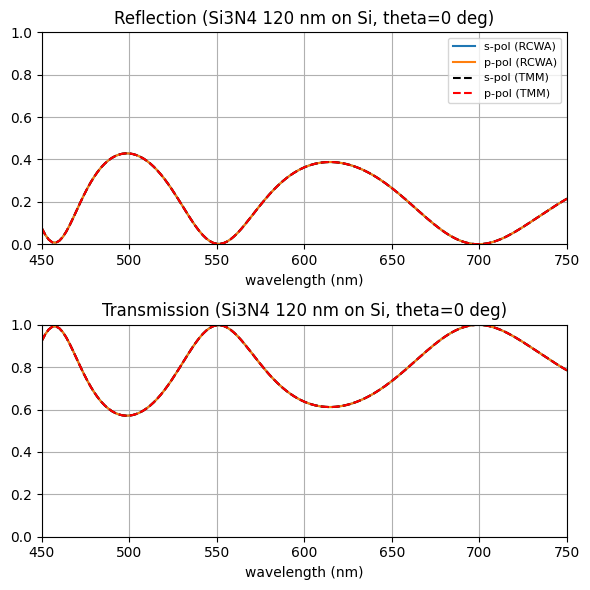

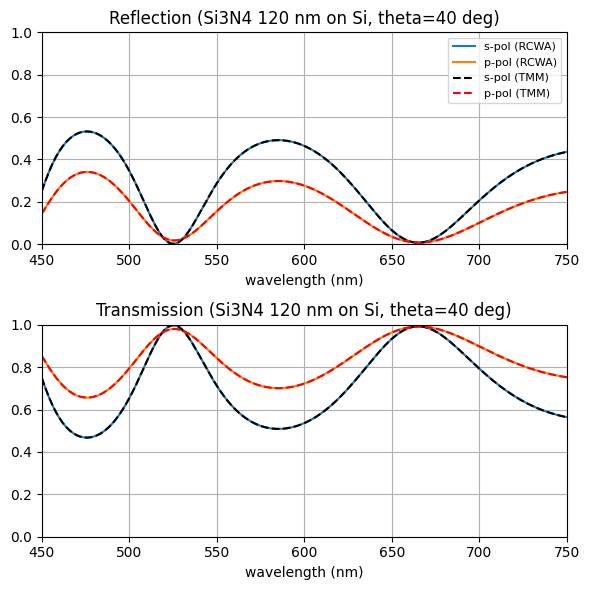

In [4]:
# --- vary incidence angle, fixed thickness ---
thickness = torch.tensor(600.0)
for th_deg in (0.0, 40.0):
    theta = torch.tensor([th_deg * math.pi / 180.0])
    model = build_model(eps_inc, eps_film, eps_sub, thickness, period, wl, theta, phi, method="homogeneous")
    Rs, Rp, Ts, Tp = compute_rt(model, config)
    Rs_t, Ts_t = tmm_rt([1.0, n_film_wl, n_sub_wl], [thickness], wl, theta.item(), pol='s')
    Rp_t, Tp_t = tmm_rt([1.0, n_film_wl, n_sub_wl], [thickness], wl, theta.item(), pol='p')
    print(f"theta={th_deg:4.1f} deg   MSE Rs={mse(Rs[:,0,0], Rs_t):.2e}   MSE Rp={mse(Rp[:,0,0], Rp_t):.2e}")
    plot_rt_vs_wl(
        wl,
        curves=(Rs[:, 0, 0], Rp[:, 0, 0], Ts[:, 0, 0], Tp[:, 0, 0]),
        theory=(Rs_t, Rp_t, Ts_t, Tp_t),
        title=f"(Si3N4 120 nm on Si, theta={th_deg:.0f} deg)",
    )

## 3. Surface plasmon resonance (Au), Kretschmann and Otto configurations

A p-polarized wave incident through a high-index prism can resonantly couple
to a surface plasmon polariton (SPP) bound to a metal/dielectric interface,
seen as a sharp dip in `Rp` (no such dip exists for s-pol -- SPPs are a
strictly TM/p-polarized mode). The SPP in-plane wavevector and the
corresponding resonance angle (beyond the prism/air critical angle) are:

```
k_spp = k0 * sqrt(eps_m * eps_d / (eps_m + eps_d))
theta_spp = asin( Re(sqrt(eps_m*eps_d/(eps_m+eps_d))) / n_prism )
```

Fixed wavelength `633 nm`, BK7-like prism `n_prism=1.515`, gold
(`dispertorch.material('Au')`) as the metal, air as the low-index dielectric.

- **Kretschmann**: prism &#8594; thin Au film (`~48 nm`) &#8594; air. The evanescent
  tail of the totally-internally-reflected wave tunnels through the thin
  metal film and couples to the SPP at the far (metal/air) interface.
- **Otto**: prism &#8594; air gap (`~600 nm`) &#8594; semi-infinite Au. The SPP lives
  at the near (air/metal) interface; the wave tunnels across the air gap
  instead of through the metal.

Both are solved via `compute_rt`/`tmm_rt` exactly as above (the metal enters
either as a finite `Layer` or directly as the semi-infinite transmission
medium -- `Stack`'s transmission half-space may be lossy).

### Kretschmann configuration

predicted theta_spp = 44.02 deg, prism/air critical angle theta_c = 41.30 deg
homogeneous vs eigen: max|dRp|=5.44e-15
RCWA vs TMM MSE: Rs=1.04e-16, Rp=1.68e-14
observed Rp dip at theta=44.63 deg, Rp_min=0.0081


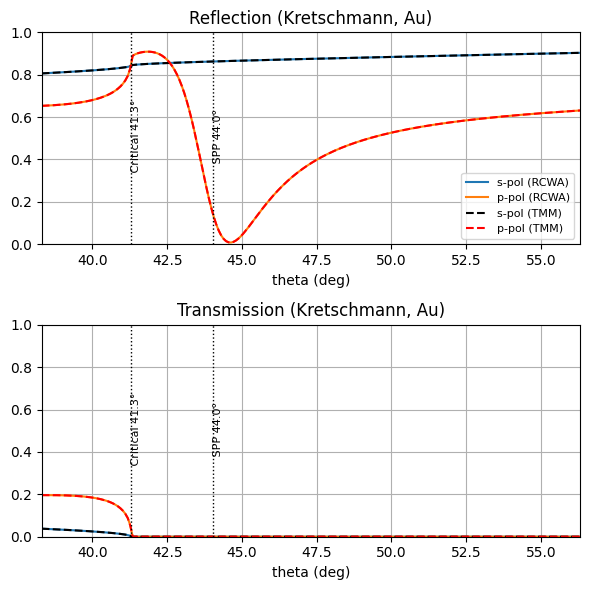

In [5]:
# Define config
dtype = torch.float64
device = "cpu"

# Define model parameters
wl0 = 633.0
n_prism = 1.515
eps_prism = ConstantEps(n_prism**2)
eps_air   = ConstantEps(1.0)
eps_au    = material('Au')
period    = 400.0

eps_au_val = eps_au(torch.tensor(wl0)).item()
n_au = eps_au_val**0.5
theta_spp = math.degrees(math.asin(((eps_au_val / (eps_au_val + 1.0))**0.5).real / n_prism))
theta_c   = math.degrees(math.asin(1.0 / n_prism))
print(f"predicted theta_spp = {theta_spp:.2f} deg, prism/air critical angle theta_c = {theta_c:.2f} deg")

config = build_config(dtype, device)
d_au = torch.tensor(40.0)   # nm
theta = torch.linspace(theta_c - 3.0, theta_c + 15.0, 220) * math.pi / 180.0
wl = torch.tensor([wl0])
phi = torch.tensor([0.0])

model_homog = build_model(eps_prism, eps_au, eps_air, d_au, period, wl, theta, phi, method="homogeneous")
model_eigen = build_model(eps_prism, eps_au, eps_air, d_au, period, wl, theta, phi, method="eigen")
Rs_h, Rp_h, Ts_h, Tp_h = compute_rt(model_homog, config)
Rs_e, Rp_e, Ts_e, Tp_e = compute_rt(model_eigen, config)
print(f"homogeneous vs eigen: max|dRp|={(Rp_h - Rp_e).abs().max().item():.2e}")

Rs_t, Ts_t = tmm_rt([n_prism, n_au, 1.0], [float(d_au)], wl0, theta, pol='s')
Rp_t, Tp_t = tmm_rt([n_prism, n_au, 1.0], [float(d_au)], wl0, theta, pol='p')
print(f"RCWA vs TMM MSE: Rs={mse(Rs_h[0,:,0], Rs_t):.2e}, Rp={mse(Rp_h[0,:,0], Rp_t):.2e}")

theta_deg = theta * 180.0 / torch.pi
i_dip = Rp_h[0, :, 0].argmin().item()
print(f"observed Rp dip at theta={theta_deg[i_dip].item():.2f} deg, Rp_min={Rp_h[0, i_dip, 0].item():.4f}")

plot_rt_vs_theta(
    theta_deg,
    curves=(Rs_h[0, :, 0], Rp_h[0, :, 0], Ts_h[0, :, 0], Tp_h[0, :, 0]),
    theory=(Rs_t, Rp_t, Ts_t, Tp_t),
    marks=[(theta_c, f"Critical {theta_c:.1f}\u00b0"), (theta_spp, f"SPP {theta_spp:.1f}\u00b0")],
    title="(Kretschmann, Au)",
)

### Otto configuration

Same prism, wavelength, and SPP resonance angle; the finite layer is now the
**air gap** and the metal is the semi-infinite **transmission** medium. The
dip is shallower than Kretschmann's for this gap width -- SPP coupling
strength depends sensitively on the tunneling distance.

homogeneous vs eigen: max|dRp|=2.66e-15
RCWA vs TMM MSE: Rs=4.38e-15, Rp=3.92e-14
observed Rp dip at theta=43.85 deg, Rp_min=0.2232


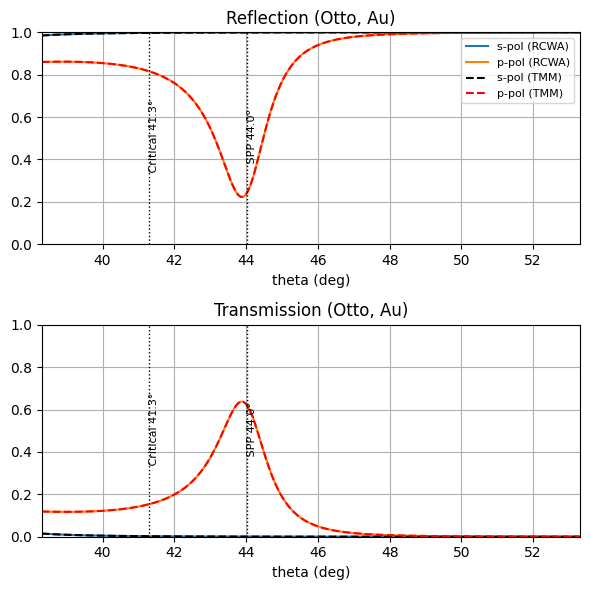

In [6]:
gap = torch.tensor(600.0)   # nm
theta_o = torch.linspace(theta_c - 3.0, theta_c + 12.0, 220) * math.pi / 180.0

model_homog_o = build_model(eps_prism, eps_air, eps_au, gap, period, wl, theta_o, phi, method="homogeneous")
model_eigen_o = build_model(eps_prism, eps_air, eps_au, gap, period, wl, theta_o, phi, method="eigen")
Rs_ho, Rp_ho, Ts_ho, Tp_ho = compute_rt(model_homog_o, config)
Rs_eo, Rp_eo, Ts_eo, Tp_eo = compute_rt(model_eigen_o, config)
print(f"homogeneous vs eigen: max|dRp|={(Rp_ho - Rp_eo).abs().max().item():.2e}")

Rs_to, Ts_to = tmm_rt([n_prism, 1.0, n_au], [float(gap)], wl0, theta_o, pol='s')
Rp_to, Tp_to = tmm_rt([n_prism, 1.0, n_au], [float(gap)], wl0, theta_o, pol='p')
print(f"RCWA vs TMM MSE: Rs={mse(Rs_ho[0,:,0], Rs_to):.2e}, Rp={mse(Rp_ho[0,:,0], Rp_to):.2e}")

theta_o_deg = theta_o * 180.0 / torch.pi
i_dip_o = Rp_ho[0, :, 0].argmin().item()
print(f"observed Rp dip at theta={theta_o_deg[i_dip_o].item():.2f} deg, Rp_min={Rp_ho[0, i_dip_o, 0].item():.4f}")

plot_rt_vs_theta(
    theta_o_deg,
    curves=(Rs_ho[0, :, 0], Rp_ho[0, :, 0], Ts_ho[0, :, 0], Tp_ho[0, :, 0]),
    theory=(Rs_to, Rp_to, Ts_to, Tp_to),
    marks=[(theta_c, f"Critical {theta_c:.1f}\u00b0"), (theta_spp, f"SPP {theta_spp:.1f}\u00b0")],
    title="(Otto, Au)",
)